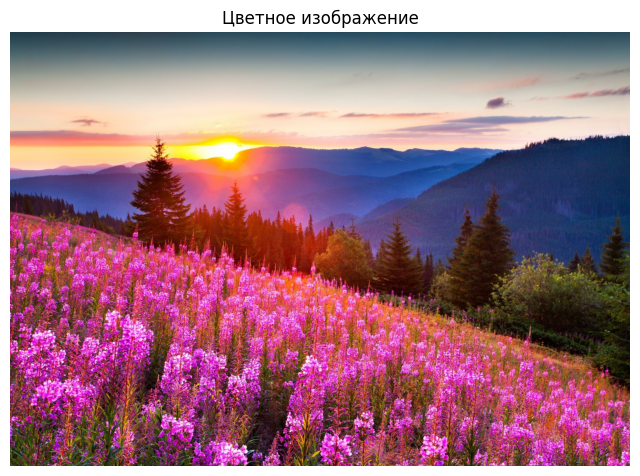

In [25]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Базовая работа с цветным изображением
image_color = cv2.imread('peizazhC.jpg')
image_color = cv2.cvtColor(image_color, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(image_color)
plt.title('Цветное изображение')
plt.axis('off')
plt.show()

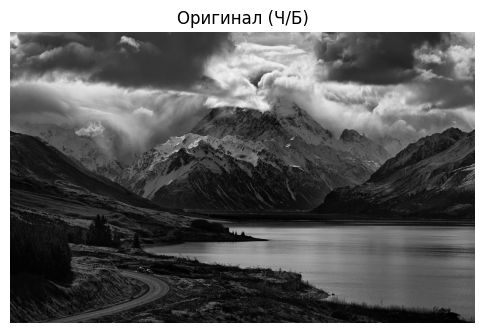

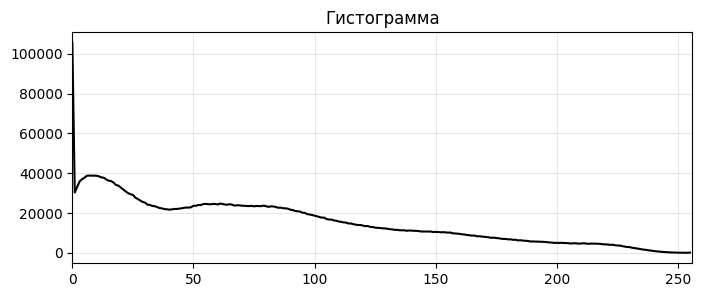

In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Загрузка изображения в оттенках серого
img_gray = cv2.imread('BWPeizazh.jpg', cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(6, 4))
plt.imshow(img_gray, cmap='gray')
plt.title('Оригинал (Ч/Б)')
plt.axis('off')
plt.show()

# 2. Построение гистограммы
hist, bins = np.histogram(img_gray.flatten(), 256, [0, 256])
plt.figure(figsize=(8, 3))
plt.plot(hist, color='black')
plt.title('Гистограмма')
plt.xlim([0, 256])
plt.grid(True, alpha=0.3)
plt.show()

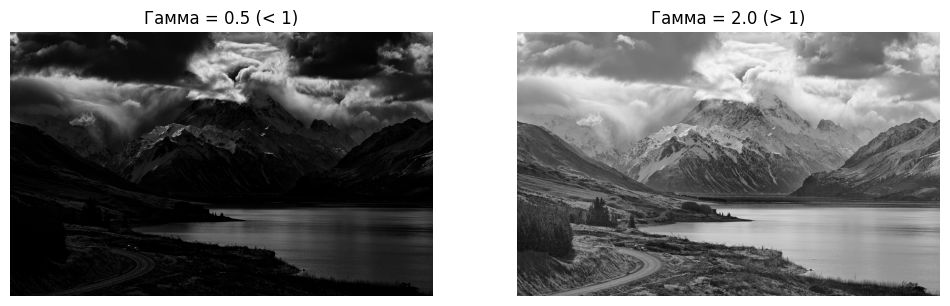

In [28]:
# 3. Гамма-коррекция
def gamma_correction(image, gamma):
    # Создаем таблицу соответствия (LUT) для ускорения вычислений
    inv_gamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** inv_gamma) * 255
                      for i in np.arange(0, 256)]).astype("uint8")
    return cv2.LUT(image, table)

# Применяем гамму < 1 (осветление) и > 1 (затемнение)
img_gamma_low = gamma_correction(img_gray, 0.5)
img_gamma_high = gamma_correction(img_gray, 2.0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.imshow(img_gamma_low, cmap='gray')
ax1.set_title('Гамма = 0.5 (< 1)')
ax2.imshow(img_gamma_high, cmap='gray')
ax2.set_title('Гамма = 2.0 (> 1)')
for ax in [ax1, ax2]: ax.axis('off')
plt.show()

In [29]:
# 4. Сравнение метриками MSE и SSIM
from skimage.metrics import structural_similarity, mean_squared_error

# Сравниваем оригинал с гаммой 0.5
ssim_low = structural_similarity(img_gray, img_gamma_low)
mse_low = mean_squared_error(img_gray, img_gamma_low)

# Сравниваем оригинал с гаммой 2.0
ssim_high = structural_similarity(img_gray, img_gamma_high)
mse_high = mean_squared_error(img_gray, img_gamma_high)

print(f"Сравнение (Гамма 0.5) -> SSIM: {ssim_low:.4f}, MSE: {mse_low:.2f}")
print(f"Сравнение (Гамма 2.0) -> SSIM: {ssim_high:.4f}, MSE: {mse_high:.2f}")

Сравнение (Гамма 0.5) -> SSIM: 0.4585, MSE: 2043.87
Сравнение (Гамма 2.0) -> SSIM: 0.7078, MSE: 2690.58


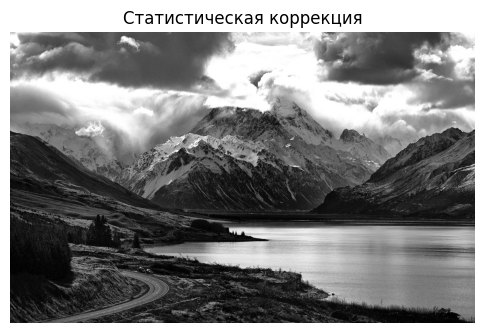

In [30]:
# 5. Статистическая цветокоррекция
eq_gray = cv2.equalizeHist(img_gray)

def match_statistics(src, ref):
    src_f = src.astype(np.float32)
    ref_f = ref.astype(np.float32)

    out = (src_f - src_f.mean()) * (ref_f.std() / (src_f.std() + 1e-8)) + ref_f.mean()
    return np.clip(out, 0, 255).astype(np.uint8)

stat_corrected = match_statistics(img_gray, eq_gray)

plt.figure(figsize=(6, 4))
plt.imshow(stat_corrected, cmap='gray')
plt.title('Статистическая коррекция')
plt.axis('off')
plt.show()

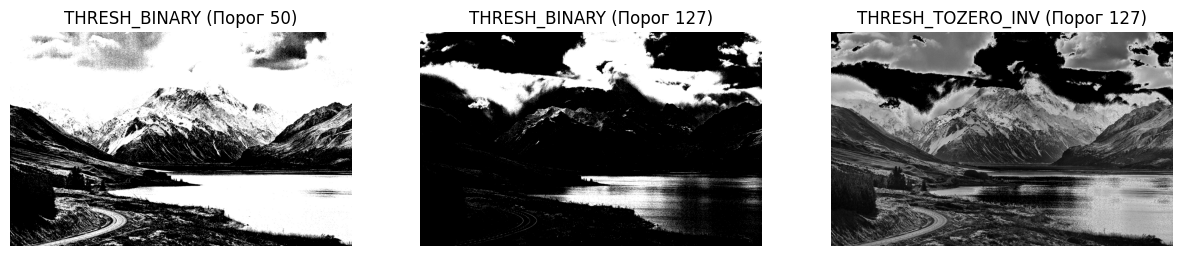

In [31]:
# 6. Пороговая фильтрация
# Обычный бинарный порог
_, thresh_50 = cv2.threshold(img_gray, 50, 255, cv2.THRESH_BINARY)
_, thresh_127 = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)
# Инвертированный порог до нуля
_, thresh_tozero_inv = cv2.threshold(img_gray, 127, 255, cv2.THRESH_TOZERO_INV)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(thresh_50, cmap='gray')
axes[0].set_title('THRESH_BINARY (Порог 50)')
axes[1].imshow(thresh_127, cmap='gray')
axes[1].set_title('THRESH_BINARY (Порог 127)')
axes[2].imshow(thresh_tozero_inv, cmap='gray')
axes[2].set_title('THRESH_TOZERO_INV (Порог 127)')
for ax in axes: ax.axis('off')
plt.show()